# Test cases for the final fit

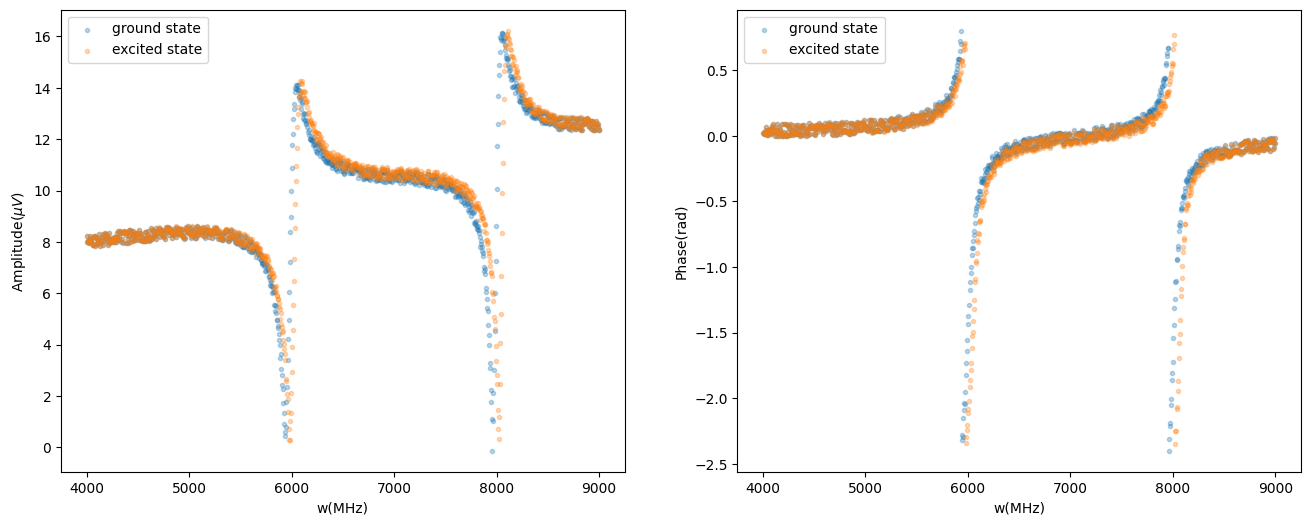

In [53]:
# generating the data
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import random

from importlib import reload
import purcell

reload(purcell)

from purcell import s_out_in

# range of frequencies
x = (1e3)*np.linspace(4,9,1001)

# convention for parameters ordering: A,k,w_0,phi,k_p,w_p,w_r,J
params_0 = [10,2,2000,0.8,2e2,6.9e3,7.1e3,1000] # for ground state 0
params_1 = [10,2,2000,0.8,2e2,6.9e3,7.2e3,1000] # for excited state 1

data_0 = s_out_in(x, *params_0)
data_1 = s_out_in(x, *params_1)

# adding noise and error bars
amp_noise = (random(len(data_0))-0.5)/2
phase_noise = (random(len(data_0))-0.5)/10

# Create figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left subplot: absolute amplitude
axes[0].scatter(x,abs(data_0) + amp_noise, label="ground state", marker=".", alpha=0.3)
axes[0].scatter(x,abs(data_1) + amp_noise, label="excited state", marker=".", alpha=0.3)
axes[0].set_ylabel(r"Amplitude($\mu V$)")
axes[0].set_xlabel("w(MHz)")
axes[0].legend()

# Right subplot: phase
axes[1].scatter(x,np.angle(data_0) + phase_noise, label="ground state",marker=".", alpha=0.3)
axes[1].scatter(x,np.angle(data_1) + phase_noise, label="excited state",marker=".", alpha=0.3)
axes[1].set_ylabel("Phase(rad)")
axes[1].set_xlabel("w(MHz)")
axes[1].legend()

Peak indices: [388 792]
Peak heights: [-13.2543135  -15.59125681]
Peak widths at 90% height: [163.80972028 372.91136876]
Parameters ordering: phi,k_p,w_p,w_r,J
Fitted parameters: [   0.77096204  201.18854601 6904.6693346  7089.92464693 1001.28034032]
Normalized differences from ideal parameters: [0.03629745 0.00594273 0.00067672 0.00141906 0.00128034]
Std_dev matrix: 
 [[0.00070398 0.01310746 0.01787937 0.01930654 0.00662218]
 [0.01310746 0.89612018 0.56701377 0.39566375 0.13599819]
 [0.01787937 0.56701377 4.17822774 4.16103921 1.42497415]
 [0.01930654 0.39566375 4.16103921 4.16492647 1.42630273]
 [0.00662218 0.13599819 1.42497415 1.42630273 0.51940215]]


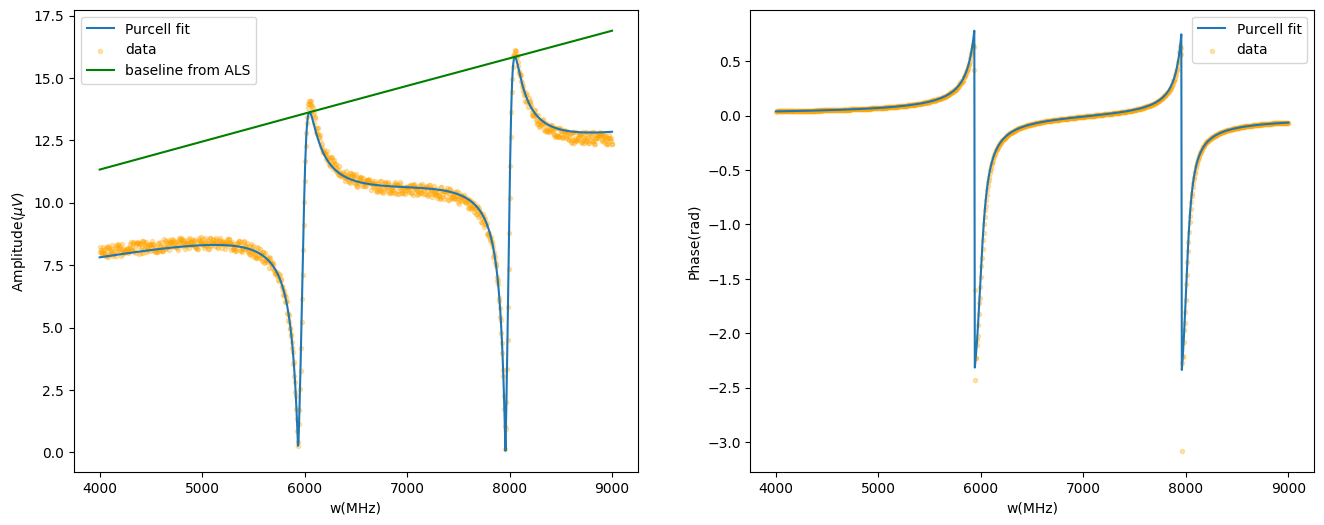

In [60]:
from importlib import reload
import purcell

reload(purcell)

from purcell import fit_purcell

cov, params = fit_purcell(frequencies=x, data=data_0+amp_noise)
print("Parameters ordering: phi,k_p,w_p,w_r,J")
print(f"Fitted parameters: {params}")
print(f"Normalized differences from ideal parameters: {abs(params-params_0[3:])/params_0[3:]}")
np.set_printoptions(precision=8, suppress=True, linewidth=100)
print(f"Std_dev matrix: \n {np.sqrt(abs(cov))}")
